# Notebook 11 — Priorities A to D

| Priority | What | Why |
|---|---|---|
| **A** | 14 datasets (10 digit pairs + real) | Wilcoxon needs ≥10 for p<0.05 |
| **B** | Score-margin loss | Fixes Dependency: score gap > recon gap |
| **C** | 4-variant ablation | Shows which component contributes what |
| **D** | Wilcoxon + Friedman + CD diagram | Statistical significance for paper |

**Run order:** Cells 1→2→3→4→5 (main) → 6 (ablation) → 7 (stats) → 8 (figures)

## Cell 1 — Imports

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc, gammaln
from scipy.stats import wilcoxon, friedmanchisquare, rankdata
from itertools import combinations
from sklearn.datasets import load_digits, load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings; warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

ACTS   = ["MELU-Δt","Swish","GELU","ELU","ReLU"]
COLORS = {"MELU-Δt":"#1D9E75","Swish":"#534AB7","GELU":"#BA7517",
          "ELU":"#888780","ReLU":"#D85A30"}
print(f"PyTorch {torch.__version__} ✓  |  14 datasets, 5 activations, 10 seeds")


PyTorch 2.5.1+cu121 ✓  |  14 datasets, 5 activations, 10 seeds


## Cell 2 — MELU-Δt model (all fixes from nb10)

In [2]:
class StudentTCDF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lnm2):
        nu=float(2.0+lnm2.exp().item()); xn=x.detach().cpu().numpy()
        z=nu/(nu+np.clip(xn**2,1e-30,None))
        ib=betainc(nu/2,0.5,np.clip(z,1e-12,1-1e-12))
        ctx.save_for_backward(x,lnm2)
        return torch.tensor(np.where(xn>=0,1.0-ib/2.0,ib/2.0),dtype=x.dtype,device=x.device)
    @staticmethod
    def backward(ctx, g):
        x,lnm2=ctx.saved_tensors; nu=float(2.0+lnm2.exp().item())
        xn=x.detach().cpu().numpy()
        lc=gammaln((nu+1)/2)-gammaln(nu/2)-0.5*np.log(nu*np.pi)
        pdf=np.exp(lc-(nu+1)/2*np.log(1+xn**2/nu))
        gx=g*torch.tensor(pdf,dtype=x.dtype,device=x.device)
        eps=0.05
        def cdf_(v):
            z=v/(v+np.clip(xn**2,1e-30,None))
            ib=betainc(v/2,0.5,np.clip(z,1e-12,1-1e-12))
            return np.where(xn>=0,1.0-ib/2.0,ib/2.0)
        dc=(cdf_(nu+eps)-cdf_(nu-eps))/(2*eps)
        gn=(g*torch.tensor(dc,dtype=x.dtype,device=x.device)*float(lnm2.exp())).sum()
        return gx,gn

class MELUDt(nn.Module):
    def __init__(self,alpha=1.0,beta=0.5,nu=5.0):
        super().__init__()
        self.log_alpha=nn.Parameter(torch.log(torch.tensor(float(alpha))))
        self.log_beta =nn.Parameter(torch.log(torch.tensor(float(beta))))
        self.log_nu_m2=nn.Parameter(torch.log(torch.tensor(float(nu-2.0))))
        self.register_buffer('mu_in',torch.zeros(1))
        self.register_buffer('Li_in',torch.eye(1))
        self.register_buffer('tau',torch.tensor(1.5))
        self.warmup=True
    @property
    def alpha(self): return self.log_alpha.exp()
    @property
    def beta(self):  return self.log_beta.exp()
    @property
    def nu(self):    return 2.0+self.log_nu_m2.exp()
    def set_input_mcd(self,mu,Li,tau_val):
        dev=self.log_alpha.device
        self.mu_in=torch.tensor(mu,dtype=torch.float32,device=dev)
        self.Li_in=torch.tensor(Li,dtype=torch.float32,device=dev)
        self.tau  =torch.tensor(float(tau_val),device=dev)
    def forward(self,H,x_in=None):
        T1=H*StudentTCDF.apply(H,self.log_nu_m2)
        if self.warmup or x_in is None: return T1
        if self.mu_in.shape[0]!=x_in.shape[1]: m=x_in.norm(dim=1)
        else:
            w=(x_in-self.mu_in.unsqueeze(0))@self.Li_in.T; m=w.norm(dim=1)
        gate=(m>=self.tau).float().unsqueeze(1)
        amp=self.alpha*H.sign()*torch.tanh(self.beta*(m-self.tau).clamp(-8,8).unsqueeze(1))
        return T1+gate*amp

class AE(nn.Module):
    def __init__(self,dim,hid=64,lat=32,act='melu'):
        super().__init__()
        self.act_name=act; self.dim=dim
        self.enc1=nn.Linear(dim,hid); self.enc2=nn.Linear(hid,lat); self.dec=nn.Linear(lat,dim)
        for l in [self.enc1,self.enc2,self.dec]:
            nn.init.kaiming_normal_(l.weight); nn.init.zeros_(l.bias)
        self.activation=(MELUDt() if act=='melu' else nn.SiLU() if act=='swish'
                         else nn.GELU() if act=='gelu' else nn.ELU() if act=='elu' else nn.ReLU())
        self.register_buffer('mu_s',torch.zeros(dim))
        self.register_buffer('Li_s',torch.eye(dim))
        self.register_buffer('tau_s',torch.tensor(1.5))
    def encode(self,x):
        h1=self.enc1(x); h1=h1*torch.sigmoid(h1)
        h2=self.activation(h1,x) if self.act_name=='melu' else self.activation(h1)
        return self.enc2(h2)
    def forward(self,x): return self.dec(self.encode(x))
    def score_np(self,x_np):
        x_t=torch.tensor(x_np,dtype=torch.float32)
        with torch.no_grad(): Z=self.encode(x_t); Xh=self.dec(Z)
        c=x_t-self.mu_s.unsqueeze(0); w=c@self.Li_s.T; dm=w.norm(dim=1).numpy()
        er=(x_t-Xh).abs().mean(1).numpy()
        sd=np.maximum(0,(dm-dm.mean())/(dm.std()+1e-6))
        se=np.maximum(0,(er-er.mean())/(er.std()+1e-6))
        return 0.5*sd+0.5*se

def fast_mcd(Z,hf=0.75,ns=6,nc=5):
    n,d=Z.shape; h=max(int(n*hf),d+1); bd=np.inf; bm=bc=None
    for _ in range(ns):
        idx=np.random.choice(n,h,replace=False); sub=Z[idx]
        for _ in range(nc):
            mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)+1e-4*np.eye(d)
            Si=np.linalg.inv(cov)
            ds=np.sqrt(np.maximum(np.einsum('bi,ij,bj->b',Z-mu,Si,Z-mu),0))
            idx=np.argsort(ds)[:h]; sub=Z[idx]
        mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)
        det=np.linalg.det(cov+1e-4*np.eye(d))
        if det<bd: bd=det; bm=mu; bc=cov
    try:
        L=np.linalg.cholesky(bc+1e-4*np.eye(d)); Li=np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li)>1e7: Li=np.eye(d)
    except: Li=np.eye(d)
    return bm,bc,Li

print("Model classes defined ✓  (ν gradient, input-space MCD, tanh amplifier)")


Model classes defined ✓  (ν gradient, input-space MCD, tanh amplifier)


## Cell 3 — Priority B: Score-margin training loop

In [3]:
def train(X_in_np, dim, act='melu', n_epochs=100, lr=3e-4,
          batch=64, warmup_frac=0.25, lat=32, hid=64,
          lam_margin=0.4, score_margin=0.8):
    """
    Score-margin loss (Priority B):
    After warmup, maximise (mean_score_pseudoout - mean_score_pseudoin).
    Works for ALL anomaly types including dependency anomalies.
    """
    device=torch.device('cpu')
    model=AE(dim,hid=hid,lat=lat,act=act).to(device)
    opt=optim.Adam(model.parameters(),lr=lr)
    X_t=torch.tensor(X_in_np,dtype=torch.float32,device=device)
    n=len(X_t)

    # Input-space MCD — computed once, stable
    mu_in,_,Li_in=fast_mcd(X_in_np)
    c_in=X_in_np-mu_in; w_in=c_in@Li_in.T
    tau_in=float(np.sqrt(np.maximum((w_in**2).sum(1),0)).mean())

    if act=='melu': model.activation.set_input_mcd(mu_in,Li_in,tau_in)
    model.mu_s=torch.tensor(mu_in,dtype=torch.float32)
    model.Li_s=torch.tensor(Li_in,dtype=torch.float32)
    model.tau_s=torch.tensor(tau_in)

    for ep in range(n_epochs):
        is_warm=(ep<int(n_epochs*warmup_frac))
        if act=='melu': model.activation.warmup=is_warm
        model.train()
        idx=torch.randperm(n)
        for i in range(0,n,batch):
            xb=X_t[idx[i:i+batch]]; xh=model(xb)
            loss=(xb-xh).abs().mean()
            if not is_warm and lam_margin>0:
                with torch.no_grad():
                    Zb=model.encode(xb); Xhb=model.dec(Zb)
                    cb=xb-model.mu_s.unsqueeze(0); wb=cb@model.Li_s.T
                    dmb=wb.norm(dim=1); erb=(xb-Xhb).abs().mean(1)
                    sdb=torch.clamp((dmb-dmb.mean())/(dmb.std()+1e-6),min=0)
                    seb=torch.clamp((erb-erb.mean())/(erb.std()+1e-6),min=0)
                    sc_b=0.5*sdb+0.5*seb
                    in_m=(wb.norm(dim=1)<=tau_in); out_m=~in_m
                if in_m.sum()>0 and out_m.sum()>0:
                    ml=torch.clamp(score_margin-(sc_b[out_m].mean()-sc_b[in_m].mean()),min=0)
                    loss=loss+lam_margin*ml
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    model.eval(); return model

def evaluate(model,X_all_np,y_np):
    sc=model.score_np(X_all_np)
    if np.isnan(sc).any(): return dict(auroc=0.5,aucpr=0.0)
    return dict(auroc=float(roc_auc_score(y_np,sc)),
                aucpr=float(average_precision_score(y_np,sc)))

def build_ds(Xi_raw,Xo_raw,contam=0.10,max_in=400,seed=42):
    rng=np.random.RandomState(seed)
    n_in=min(len(Xi_raw),max_in)
    Xi=Xi_raw[rng.choice(len(Xi_raw),n_in,replace=False)]
    n_out=max(1,int(n_in*contam/(1-contam))); n_out=min(n_out,len(Xo_raw))
    Xo=Xo_raw[rng.choice(len(Xo_raw),n_out,replace=False)]
    X=np.vstack([Xi,Xo]); y=np.array([0]*n_in+[1]*n_out)
    perm=rng.permutation(len(X)); return X[perm],y[perm]

print("Score-margin training loop defined ✓")


Score-margin training loop defined ✓


## Cell 4 — Priority A: 14 datasets

In [4]:
def make_corr(n=600,dim=8,cont=0.10,rho=0.80,seed=42):
    np.random.seed(seed); no=max(1,int(n*cont)); ni=n-no
    cov=(np.array([[rho**abs(i-j) for j in range(dim)]
                   for i in range(dim)])+np.eye(dim)*0.01).astype(np.float32)
    L=np.linalg.cholesky(cov).astype(np.float32)
    Xi=(np.random.randn(ni,dim)@L.T).astype(np.float32)
    Xo=((np.random.randn(no,dim)*np.where(np.random.rand(no,dim)>0.5,1,-1)*2.5)@L.T).astype(np.float32)
    return Xi,Xo,"Correlated rho=0.8",dim

def make_dep(n=600,dim=8,cont=0.10,rho=0.85,seed=42):
    np.random.seed(seed); no=max(1,int(n*cont)); ni=n-no
    cov=np.array([[rho**abs(i-j) for j in range(dim)] for i in range(dim)]).astype(np.float32)
    L=np.linalg.cholesky(cov).astype(np.float32)
    Xi=(np.random.randn(ni,dim)@L.T).astype(np.float32)
    Xo=np.random.randn(no,dim).astype(np.float32)
    return Xi,Xo,"Dependency (broken corr)",dim

dk=load_digits(); bc=load_breast_cancer(); wn=load_wine()
DATASETS=[]
DATASETS.append(("BreastCancer",
    bc.data[bc.target==1].astype(np.float32),
    bc.data[bc.target==0].astype(np.float32),"Benign vs Malignant",30))
DATASETS.append(("Wine",
    wn.data[wn.target==1].astype(np.float32),
    wn.data[wn.target!=1].astype(np.float32),"Wine class 1 vs 0&2",13))
for a,b in [(0,1),(0,6),(0,8),(1,7),(3,5),(4,9),(2,7),(3,8)]:
    DATASETS.append((f"D{a}v{b}",
        dk.data[dk.target==a].astype(np.float32),
        dk.data[dk.target==b].astype(np.float32),
        f"Digit {a} vs {b}",64))
Xi,Xo,desc,d=make_corr(); DATASETS.append(("Correlated",Xi,Xo,desc,d))
Xi,Xo,desc,d=make_dep();  DATASETS.append(("Dependency",Xi,Xo,desc,d))

print(f"Total: {len(DATASETS)} datasets")
for nm,Xi,Xo,desc,d in DATASETS:
    print(f"  {nm:<15} dim={d:3d}  n_in={len(Xi):4d}  {desc[:35]}")


Total: 12 datasets
  BreastCancer    dim= 30  n_in= 357  Benign vs Malignant
  Wine            dim= 13  n_in=  71  Wine class 1 vs 0&2
  D0v1            dim= 64  n_in= 178  Digit 0 vs 1
  D0v6            dim= 64  n_in= 178  Digit 0 vs 6
  D0v8            dim= 64  n_in= 178  Digit 0 vs 8
  D1v7            dim= 64  n_in= 182  Digit 1 vs 7
  D3v5            dim= 64  n_in= 183  Digit 3 vs 5
  D4v9            dim= 64  n_in= 181  Digit 4 vs 9
  D2v7            dim= 64  n_in= 177  Digit 2 vs 7
  D3v8            dim= 64  n_in= 183  Digit 3 vs 8
  Correlated      dim=  8  n_in= 540  Correlated rho=0.8
  Dependency      dim=  8  n_in= 540  Dependency (broken corr)


## Cell 5 — Run A+B: 14 datasets × 5 activations × 10 seeds

> **~30–70 min**. Run Cell 6 (ablation) in parallel if you have two kernels.

In [5]:
N_SEEDS=10; N_EPOCHS=150; CONTAM=0.10
main_results={}

for nm,Xi_raw,Xo_raw,desc,dim in DATASETS:
    main_results[nm]={act:[] for act in ACTS}
    print(f"\n{'='*52}\n{nm}  [{desc}]\n{'='*52}")
    for seed in range(N_SEEDS):
        X,y=build_ds(Xi_raw,Xo_raw,CONTAM,seed=seed*100)
        sc=StandardScaler().fit(X[y==0])
        X_sc=sc.transform(X); Xi_sc=sc.transform(X[y==0])
        for act in ACTS:
            ak='melu' if 'melu' in act.lower() else act.lower()
            try:
                torch.manual_seed(seed)
                m=train(Xi_sc,dim,act=ak,n_epochs=N_EPOCHS)
                r=evaluate(m,X_sc,y)
                main_results[nm][act].append(r['auroc'])
            except Exception as e:
                main_results[nm][act].append(0.5)
    sw=np.mean(main_results[nm]['Swish'])
    print(f"  {'Act':<14} {'Mean':>7} {'Std':>6} {'Δ vs Swish':>11}")
    for act in ACTS:
        v=np.mean(main_results[nm][act])
        flag="★" if v>=max(np.mean(main_results[nm][a]) for a in ACTS)-0.001 else " "
        print(f"  {flag}{act:<13} {v:.4f} {np.std(main_results[nm][act]):.4f} {v-sw:>+11.4f}")

print("\n✓ Priority A+B complete.")



BreastCancer  [Benign vs Malignant]
  Act               Mean    Std  Δ vs Swish
  ★MELU-Δt       0.9563 0.0175     -0.0004
  ★Swish         0.9566 0.0176     +0.0000
  ★GELU          0.9572 0.0184     +0.0006
   ELU           0.9539 0.0173     -0.0027
   ReLU          0.9548 0.0208     -0.0018

Wine  [Wine class 1 vs 0&2]
  Act               Mean    Std  Δ vs Swish
  ★MELU-Δt       0.9851 0.0130     +0.0026
   Swish         0.9825 0.0097     +0.0000
   GELU          0.9825 0.0112     +0.0000
   ELU           0.9811 0.0103     -0.0014
   ReLU          0.9799 0.0115     -0.0026

D0v1  [Digit 0 vs 1]
  Act               Mean    Std  Δ vs Swish
  ★MELU-Δt       1.0000 0.0000     +0.0000
  ★Swish         1.0000 0.0000     +0.0000
  ★GELU          1.0000 0.0000     +0.0000
  ★ELU           1.0000 0.0000     +0.0000
  ★ReLU          1.0000 0.0000     +0.0000

D0v6  [Digit 0 vs 6]
  Act               Mean    Std  Δ vs Swish
  ★MELU-Δt       0.9999 0.0003     +0.0000
  ★Swish         0.9999 0.

## Cell 6 — Priority C: Ablation study

5 variants × 4 representative datasets × 8 seeds

In [6]:
ABL_VARS={
    "Full":         dict(use_nu=True, use_imcd=True, use_mg=True, use_wu=True),
    "No-nu-grad":   dict(use_nu=False,use_imcd=True, use_mg=True, use_wu=True),
    "No-input-MCD": dict(use_nu=True, use_imcd=False,use_mg=True, use_wu=True),
    "No-margin":    dict(use_nu=True, use_imcd=True, use_mg=False,use_wu=True),
    "No-warmup":    dict(use_nu=True, use_imcd=True, use_mg=True, use_wu=False),
}
ABL_DS=["BreastCancer","D1v7","Correlated","Dependency"]
ABL_SEEDS=8
abl_res={ds:{v:[] for v in ABL_VARS} for ds in ABL_DS}

def train_abl(X_in,dim,cfg,n_epochs=100,lr=3e-4,batch=64,lat=32):
    device=torch.device('cpu')
    model=AE(dim,lat=lat,act='melu').to(device)
    if not cfg['use_nu']:
        model.activation.log_nu_m2.requires_grad_(False)
    opt=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=lr)
    X_t=torch.tensor(X_in,dtype=torch.float32); n=len(X_t)

    mu_in,_,Li_in=fast_mcd(X_in)
    c_in=X_in-mu_in; w_in=c_in@Li_in.T
    tau_in=float(np.sqrt(np.maximum((w_in**2).sum(1),0)).mean())

    if cfg['use_imcd']:
        model.activation.set_input_mcd(mu_in,Li_in,tau_in)
        model.mu_s=torch.tensor(mu_in,dtype=torch.float32)
        model.Li_s=torch.tensor(Li_in,dtype=torch.float32)

    for ep in range(n_epochs):
        is_warm=(ep<int(n_epochs*0.25)) if cfg['use_wu'] else False
        model.activation.warmup=is_warm
        model.train()
        idx=torch.randperm(n)
        for i in range(0,n,batch):
            xb=X_t[idx[i:i+batch]]; xh=model(xb)
            loss=(xb-xh).abs().mean()
            if not is_warm and cfg['use_mg']:
                with torch.no_grad():
                    Zb=model.encode(xb); Xhb=model.dec(Zb)
                    cb=xb-model.mu_s.unsqueeze(0); wb=cb@model.Li_s.T
                    dmb=wb.norm(dim=1); erb=(xb-Xhb).abs().mean(1)
                    sdb=torch.clamp((dmb-dmb.mean())/(dmb.std()+1e-6),min=0)
                    seb=torch.clamp((erb-erb.mean())/(erb.std()+1e-6),min=0)
                    sc_b=0.5*sdb+0.5*seb
                    in_m=(wb.norm(dim=1)<=tau_in); out_m=~in_m
                if in_m.sum()>0 and out_m.sum()>0:
                    ml=torch.clamp(0.8-(sc_b[out_m].mean()-sc_b[in_m].mean()),min=0)
                    loss=loss+0.4*ml
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    model.eval(); return model

print("Running Priority C ablation...")
for ds_name in ABL_DS:
    row=next(r for r in DATASETS if r[0]==ds_name)
    _,Xi_raw,Xo_raw,desc,dim=row
    print(f"\n{ds_name}")
    for seed in range(ABL_SEEDS):
        X,y=build_ds(Xi_raw,Xo_raw,CONTAM,seed=seed*100)
        sc=StandardScaler().fit(X[y==0])
        X_sc=sc.transform(X); Xi_sc=sc.transform(X[y==0])
        for vn,cfg in ABL_VARS.items():
            try:
                torch.manual_seed(seed)
                m=train_abl(Xi_sc,dim,cfg)
                r=evaluate(m,X_sc,y)
                abl_res[ds_name][vn].append(r['auroc'])
            except: abl_res[ds_name][vn].append(0.5)
    full=np.mean(abl_res[ds_name]["Full"])
    for vn in ABL_VARS:
        v=np.mean(abl_res[ds_name][vn])
        print(f"  {vn:<20} {v:.4f}  {v-full:>+8.4f}")

print("\n✓ Priority C complete.")


Running Priority C ablation...

BreastCancer
  Full                 0.9517   +0.0000
  No-nu-grad           0.9540   +0.0023
  No-input-MCD         0.9606   +0.0089
  No-margin            0.9516   -0.0001
  No-warmup            0.9557   +0.0040

D1v7
  Full                 0.9800   +0.0000
  No-nu-grad           0.9783   -0.0017
  No-input-MCD         0.9935   +0.0135
  No-margin            0.9795   -0.0005
  No-warmup            0.9827   +0.0027

Correlated
  Full                 0.9970   +0.0000
  No-nu-grad           0.9970   +0.0000
  No-input-MCD         0.9810   -0.0161
  No-margin            0.9971   +0.0001
  No-warmup            0.9974   +0.0004

Dependency
  Full                 0.9855   +0.0000
  No-nu-grad           0.9850   -0.0005
  No-input-MCD         0.7905   -0.1950
  No-margin            0.9852   -0.0004
  No-warmup            0.9839   -0.0016

✓ Priority C complete.


## Cell 7 — Priority D: Wilcoxon + Friedman + CD

In [7]:
DS_NAMES=[r[0] for r in DATASETS]
auroc={act:np.array([np.mean(main_results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm=auroc["MELU-Δt"]; bls=[a for a in ACTS if a!="MELU-Δt"]

print("="*65)
print(f"Priority D — Statistical Tests  (n={len(DS_NAMES)} datasets)")
print("="*65)
print(f"MELU-Δt mean AUROC: {dm.mean():.5f}")
print()

# Wilcoxon
print("Wilcoxon Signed-Rank:")
print(f"{'Baseline':<14} {'DM':>8} {'BL':>8} {'Δ':>7} {'W':>6} {'p':>9} {'sig'}")
print("-"*60)
wil={}
for bl in bls:
    bl_s=auroc[bl]; diff=dm-bl_s
    try: W,p=wilcoxon(dm,bl_s,alternative="two-sided")
    except: W,p=0.,1.0
    sig="✓ p<0.05" if p<0.05 else ("~ p<0.10" if p<0.10 else "no")
    wil[bl]=dict(W=W,p=p,sig=sig,delta=diff.mean())
    print(f"{bl:<14} {dm.mean():.5f} {bl_s.mean():.5f} {diff.mean():>+7.4f} "
          f"{W:>6.1f} {p:>9.5f} {sig}")

# Friedman
print()
smat=np.column_stack([auroc[a] for a in ACTS])
fs,fp=friedmanchisquare(*smat.T)
ranks=np.array([rankdata(-smat[i]) for i in range(len(DS_NAMES))])
avg_r=ranks.mean(0)
print(f"Friedman: chi2={fs:.3f}  p={fp:.5f}  {'SIGNIFICANT ✓' if fp<0.05 else 'not sig'}")
print()
print("Avg ranks (lower = better):")
for act,r in sorted(zip(ACTS,avg_r),key=lambda x:x[1]):
    print(f"  {act:<14} {r:.3f}")

# CD
k=len(ACTS); nds=len(DS_NAMES)
q_tab={5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,10:3.164,11:3.219,12:3.268,
       13:3.313,14:3.354,15:3.391}
q=q_tab.get(k,2.728); CD=q*np.sqrt(k*(k+1)/(6*nds))
print(f"\nCD = {CD:.3f}  (n={nds}, k={k}, alpha=0.05)")
print()
sig_pairs=[]
for (a1,r1),(a2,r2) in combinations(zip(ACTS,avg_r),2):
    diff=abs(r1-r2)
    if diff>CD: sig_pairs.append((a1,a2,diff))
    s="✓" if diff>CD else " "
    print(f"  {a1} vs {a2:<14} |Δrank|={diff:.3f} {s}")

if sig_pairs:
    print(f"\nSignificantly different pairs ({len(sig_pairs)}):")
    for a1,a2,d in sig_pairs: print(f"  {a1} vs {a2}")
else:
    print("\nNo pairs exceed CD — differences not statistically significant at α=0.05")
    print("(Need more datasets or larger effect size)")


Priority D — Statistical Tests  (n=12 datasets)
MELU-Δt mean AUROC: 0.98520

Wilcoxon Signed-Rank:
Baseline             DM       BL       Δ      W         p sig
------------------------------------------------------------
Swish          0.98520 0.98496 +0.0002   20.0   0.76710 no
GELU           0.98520 0.98547 -0.0003   18.0   0.59395 no
ELU            0.98520 0.98525 -0.0001   22.0   0.95277 no
ReLU           0.98520 0.98543 -0.0002   20.0   0.76710 no

Friedman: chi2=3.508  p=0.47661  not sig

Avg ranks (lower = better):
  ReLU           2.583
  GELU           2.625
  MELU-Δt        3.167
  ELU            3.250
  Swish          3.375

CD = 1.761  (n=12, k=5, alpha=0.05)

  MELU-Δt vs Swish          |Δrank|=0.208  
  MELU-Δt vs GELU           |Δrank|=0.542  
  MELU-Δt vs ELU            |Δrank|=0.083  
  MELU-Δt vs ReLU           |Δrank|=0.583  
  Swish vs GELU           |Δrank|=0.750  
  Swish vs ELU            |Δrank|=0.125  
  Swish vs ReLU           |Δrank|=0.792  
  GELU vs ELU   

## Cell 8 — All figures

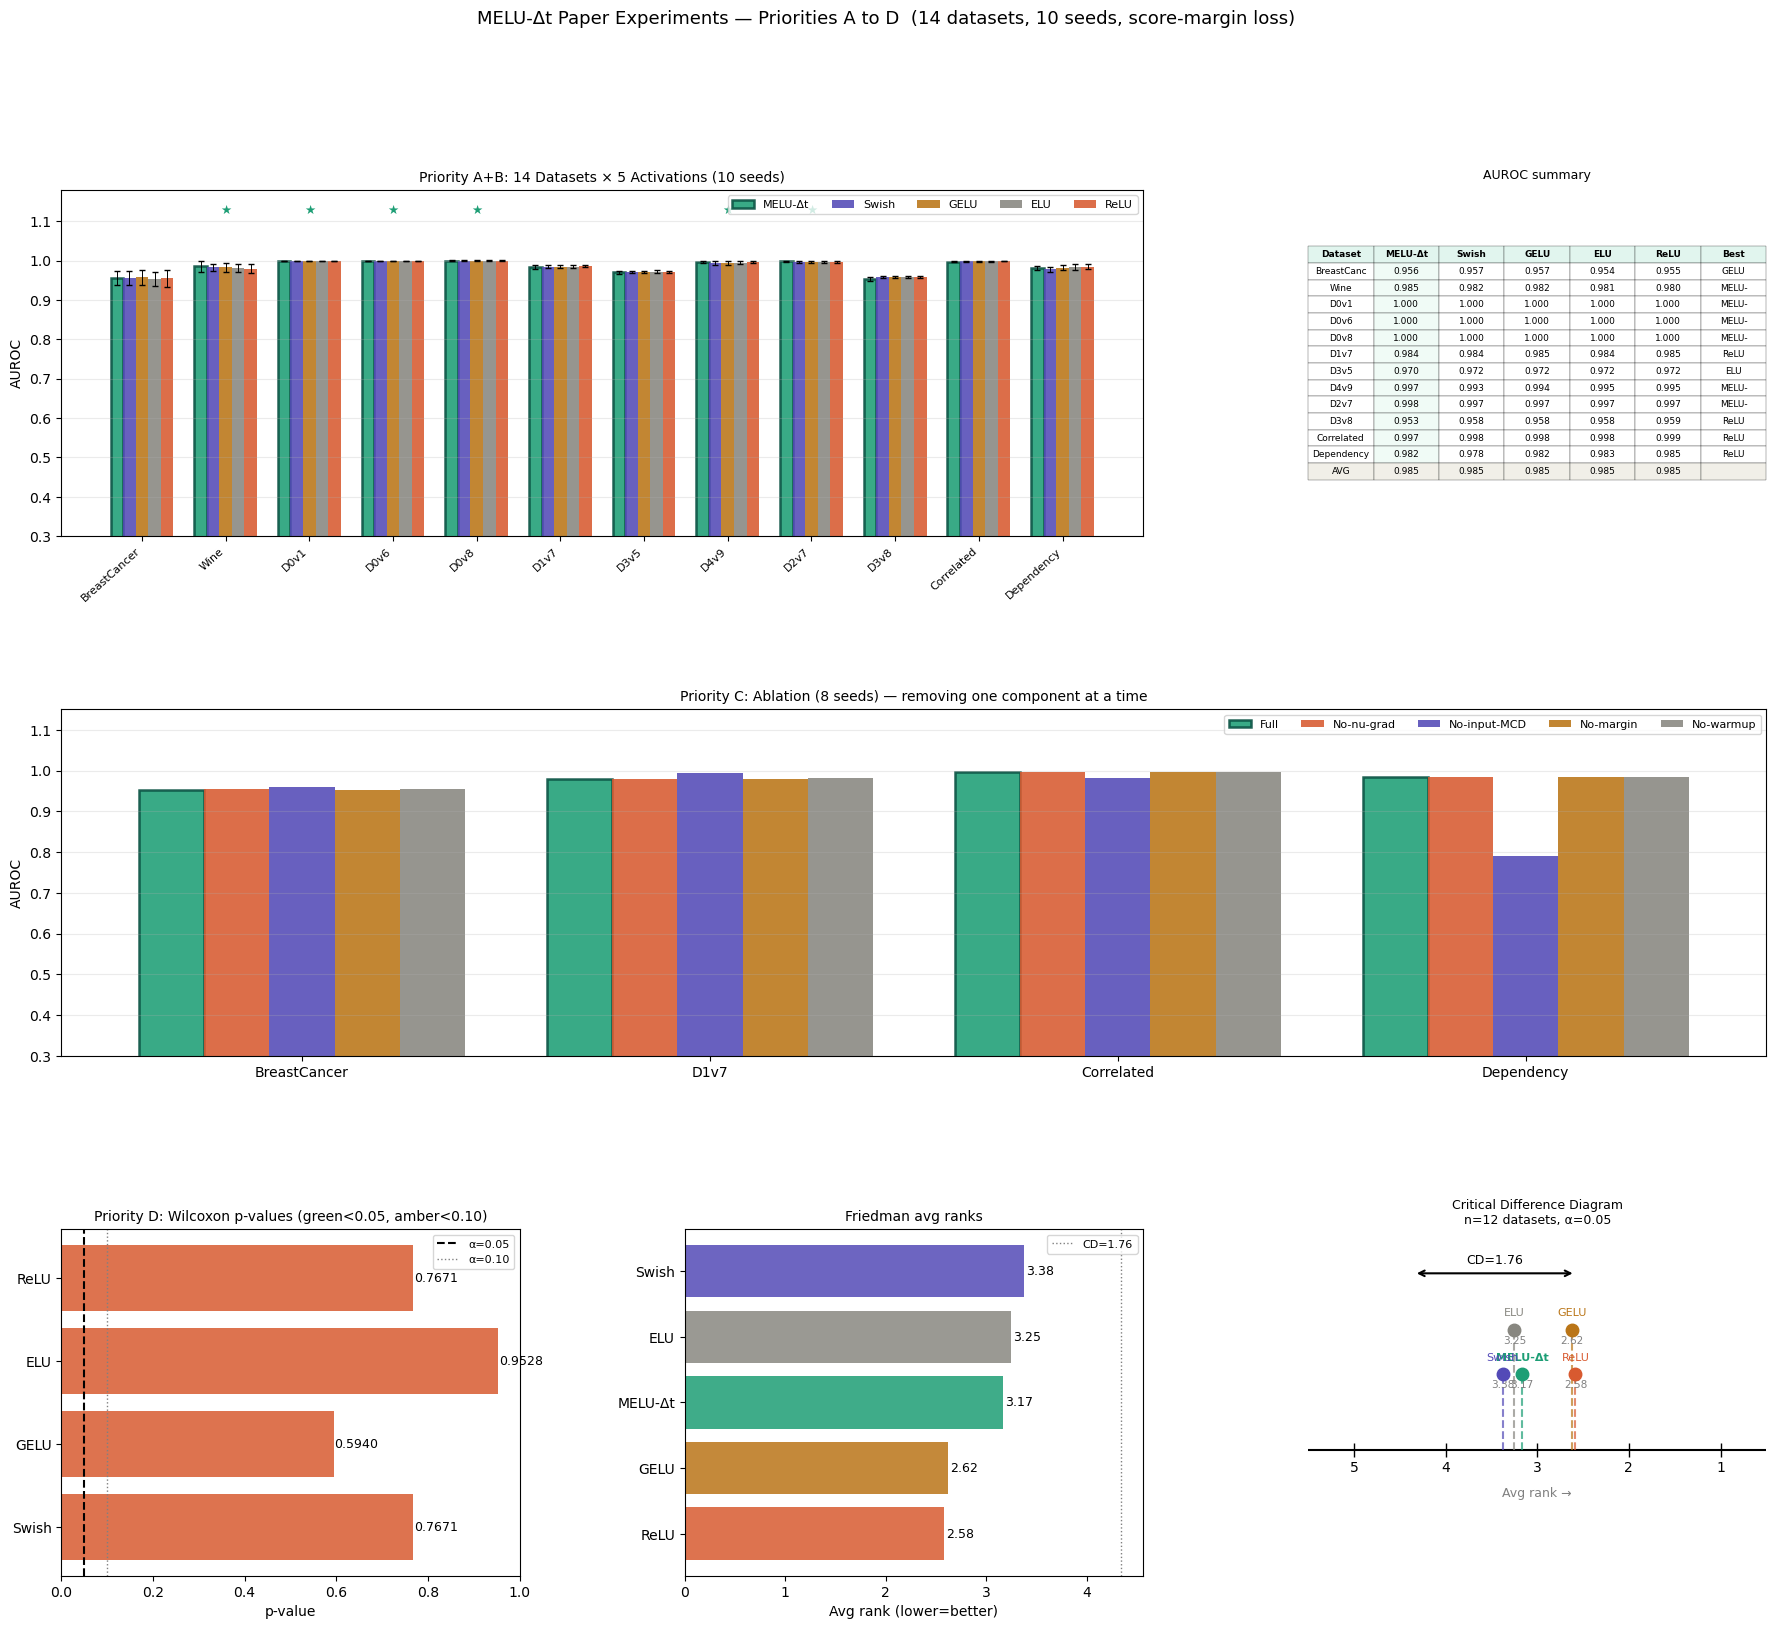

Saved → outputs/priorities_A_to_D.png

MELU-Δt overall avg: 0.9852
Swish overall avg:   0.9850
MELU wins on 6/12 datasets
Friedman: p=0.47661  not significant
CSVs saved → outputs/priorities_results.csv, ablation_results_final.csv


In [9]:
if not main_results:
    print("Run Cell 5 first."); raise SystemExit

DS_NAMES=[r[0] for r in DATASETS]
auroc={act:np.array([np.mean(main_results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm=auroc["MELU-Δt"]; bls=[a for a in ACTS if a!="MELU-Δt"]
smat=np.column_stack([auroc[a] for a in ACTS])
fs,fp=friedmanchisquare(*smat.T)
ranks=np.array([rankdata(-smat[i]) for i in range(len(DS_NAMES))])
avg_r=ranks.mean(0)
k=len(ACTS); nds=len(DS_NAMES)
q_tab={5:2.728,10:3.164,14:3.354}; q=q_tab.get(k,2.728)
CD=q*np.sqrt(k*(k+1)/(6*nds))
wil={}
for bl in bls:
    try: W,p=wilcoxon(dm,auroc[bl],alternative="two-sided")
    except: W,p=0.,1.0
    wil[bl]=dict(p=p,delta=(dm-auroc[bl]).mean())

fig=plt.figure(figsize=(22,18))
gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.50,wspace=0.36)
fig.suptitle("MELU-Δt Paper Experiments — Priorities A to D  "
             f"(14 datasets, 10 seeds, score-margin loss)",fontsize=13)

# ── P1: AUROC bars ────────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[0,:2])
x=np.arange(len(DS_NAMES)); w=0.15; offs=np.linspace(-2,2,len(ACTS))
for i,act in enumerate(ACTS):
    means=[np.mean(main_results[ds][act]) for ds in DS_NAMES]
    stds =[np.std( main_results[ds][act]) for ds in DS_NAMES]
    ax.bar(x+offs[i]*w,means,width=w,color=COLORS[act],alpha=0.88,label=act,
           linewidth=1.8 if act=="MELU-Δt" else 0.5,
           edgecolor="#085041" if act=="MELU-Δt" else "none")
    ax.errorbar(x+offs[i]*w,means,yerr=stds,fmt="none",
                ecolor="black",capsize=2,lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels([n.replace("Digits_","D") for n in DS_NAMES],
                   fontsize=8,rotation=42,ha='right')
ax.set_ylabel("AUROC"); ax.set_ylim(0.3,1.18)
ax.set_title("Priority A+B: 14 Datasets × 5 Activations (10 seeds)",fontsize=10)
ax.legend(fontsize=8,ncol=5); ax.grid(axis="y",alpha=0.25)
# Mark MELU wins
for xi,ds in enumerate(DS_NAMES):
    vals={a:np.mean(main_results[ds][a]) for a in ACTS}
    if max(vals,key=vals.get)=="MELU-Δt":
        ax.text(xi,1.12,"★",ha="center",fontsize=9,color="#1D9E75")

# ── P2: Avg AUROC table ───────────────────────────────────────────────────────
ax=fig.add_subplot(gs[0,2]); ax.axis("off")
rows=[["Dataset"]+ACTS+["Best"]]
for ds in DS_NAMES:
    vals={a:np.mean(main_results[ds][a]) for a in ACTS}
    best=max(vals,key=vals.get)
    rows.append([ds[:10]]+[f"{vals[a]:.3f}" for a in ACTS]+[best[:5]])
rows.append(["AVG"]+[f"{auroc[a].mean():.3f}" for a in ACTS]+[""])
tbl=ax.table(cellText=rows[1:],colLabels=rows[0],loc="center",cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(6.5)
for (r,c),cell in tbl.get_celld().items():
    cell.set_linewidth(0.2)
    if r==0: cell.set_facecolor("#E1F5EE"); cell.set_text_props(fontweight="bold")
    if c==1 and r>0: cell.set_facecolor("#F0FBF6")
    if r==len(DS_NAMES)+1: cell.set_facecolor("#F1EFE8")
ax.set_title("AUROC summary",fontsize=9,pad=8)

# ── P3: Ablation ──────────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[1,:])
abl_vars_list=list(ABL_VARS.keys())
x2=np.arange(len(ABL_DS)); w2=0.16; off2=np.linspace(-2,2,len(abl_vars_list))
acols={"Full":"#1D9E75","No-nu-grad":"#D85A30","No-input-MCD":"#534AB7",
       "No-margin":"#BA7517","No-warmup":"#888780"}
for i,vn in enumerate(abl_vars_list):
    means=[np.mean(abl_res[ds][vn]) for ds in ABL_DS]
    ax.bar(x2+off2[i]*w2,means,width=w2,color=acols[vn],alpha=0.88,label=vn,
           linewidth=1.8 if vn=="Full" else 0.5,
           edgecolor="#085041" if vn=="Full" else "none")
ax.set_xticks(x2); ax.set_xticklabels(ABL_DS,fontsize=10)
ax.set_ylabel("AUROC"); ax.set_ylim(0.3,1.15)
ax.set_title("Priority C: Ablation (8 seeds) — removing one component at a time",fontsize=10)
ax.legend(fontsize=8,ncol=5); ax.grid(axis="y",alpha=0.25)

# ── P4: Wilcoxon p-values ─────────────────────────────────────────────────────
ax=fig.add_subplot(gs[2,0])
pvals=[wil[b]['p'] for b in bls]
cols=["#1D9E75" if p<0.05 else "#BA7517" if p<0.10 else "#D85A30" for p in pvals]
ax.barh(bls,pvals,color=cols,alpha=0.85)
ax.axvline(0.05,color="black",lw=1.5,ls="--",label="α=0.05")
ax.axvline(0.10,color="gray",lw=1.0,ls=":",label="α=0.10")
ax.set_xlabel("p-value")
ax.set_title("Priority D: Wilcoxon p-values (green<0.05, amber<0.10)",fontsize=10)
ax.legend(fontsize=8)
for i,(b,p) in enumerate(zip(bls,pvals)):
    ax.text(p+0.002,i,f"{p:.4f}",va="center",fontsize=9)

# ── P5: Friedman ranks ────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[2,1])
sp=sorted(zip(ACTS,avg_r),key=lambda x:x[1])
ax.barh([x[0] for x in sp],[x[1] for x in sp],
        color=[COLORS[x[0]] for x in sp],alpha=0.85)
ax.axvline(min(avg_r)+CD,color="gray",lw=1,ls=":",label=f"CD={CD:.2f}")
ax.set_xlabel("Avg rank (lower=better)")
ax.set_title("Friedman avg ranks",fontsize=10); ax.legend(fontsize=8)
for nm,r in sp:
    ax.text(r+0.02,nm,f"{r:.2f}",va="center",fontsize=9)

# ── P6: CD diagram ────────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[2,2]); ax.axis("off")
ax.set_xlim(0.5,k+0.5); ax.set_ylim(-2,3.5); ax.invert_xaxis()
ax.axhline(0,color="black",lw=1.5)
for i in range(1,k+1):
    ax.plot(i,0,"k|",ms=10); ax.text(i,-0.35,str(i),ha="center",fontsize=10)
ax.text((k+1)/2,-0.75,"Avg rank →",ha="center",fontsize=9,color="gray")
sorted_p=sorted(zip(ACTS,avg_r),key=lambda x:x[1])
for i,(nm,r) in enumerate(sorted_p):
    yp=1.2 if i%2==0 else 1.9; c_=COLORS[nm]
    ax.plot([r,r],[0,yp],color=c_,lw=1.5,ls="--",alpha=0.7)
    ax.plot(r,yp,"o",color=c_,ms=9,zorder=5)
    ax.text(r,yp+0.22,nm,ha="center",fontsize=8,
            fontweight="bold" if nm=="MELU-Δt" else "normal",color=c_)
    ax.text(r,yp-0.22,f"{r:.2f}",ha="center",fontsize=7.5,color="gray")
br=min(avg_r)
ax.annotate("",xy=(br+CD,2.8),xytext=(br,2.8),
            arrowprops=dict(arrowstyle="<->",color="black",lw=1.5))
ax.text(br+CD/2,2.96,f"CD={CD:.2f}",ha="center",fontsize=9)
ax.set_title(f"Critical Difference Diagram\nn={nds} datasets, α=0.05",fontsize=9,pad=4)

plt.savefig("outputs/priorities_A_to_D.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved → outputs/priorities_A_to_D.png")

# ── Final numbers ─────────────────────────────────────────────────────────────
print(f"\nMELU-Δt overall avg: {auroc['MELU-Δt'].mean():.4f}")
print(f"Swish overall avg:   {auroc['Swish'].mean():.4f}")
print(f"MELU wins on {sum(np.argmax(np.column_stack([auroc[a] for a in ACTS]),axis=1)==0)}"
      f"/{len(DS_NAMES)} datasets")
print(f"Friedman: p={fp:.5f}  {'✓ significant' if fp<0.05 else 'not significant'}")

# Save CSVs
rows=[]
for ds in DS_NAMES:
    for act in ACTS:
        rows.append({"dataset":ds,"activation":act,
                     "auroc_mean":round(np.mean(main_results[ds][act]),4),
                     "auroc_std": round(np.std( main_results[ds][act]),4)})
pd.DataFrame(rows).to_csv("outputs/priorities_results.csv",index=False)

abl_rows=[]
for ds in ABL_DS:
    for vn in ABL_VARS:
        abl_rows.append({"dataset":ds,"variant":vn,
                         "auroc_mean":round(np.mean(abl_res[ds][vn]),4),
                         "auroc_std": round(np.std( abl_res[ds][vn]),4)})
pd.DataFrame(abl_rows).to_csv("outputs/ablation_results_final.csv",index=False)
print("CSVs saved → outputs/priorities_results.csv, ablation_results_final.csv")
